In [923]:
from IPython.display import clear_output
import glob
import pickle
from tqdm.auto import tqdm
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split
import itertools
import sys
sys.path.insert(0, '../scripts-homepage-data/')
import get_bounding_boxes_from_html as bb
import os 
import pandas as pd 
import shutil
import json
import time
from tqdm.auto import tqdm
import jsonlines

from subprocess import Popen, PIPE, run, check_call
def run_subprocess_get_output(cmd):
    output, _ = Popen(cmd.split(), stdin=PIPE, stdout=PIPE, stderr=PIPE).communicate()
    return output

In [ ]:
page, browser, playwright = await bb.instantiate_new_page_object(headless=False, block_external_files=False)

In [ ]:
await page.goto('file://' + os.getcwd() + '/../scripts/wp-20230218061849.html')

In [ ]:
await bb.draw_visual_bounding_boxes_on_page(page=page)

In [189]:
latimes_bounding_boxes = sorted(latimes_bounding_boxes, key=lambda df: df.iloc[0]['key'])

In [ ]:
await bb.draw_visual_bounding_boxes_on_page(
    file='file://' + os.getcwd() + '/' + two_years_latimes_files[0]
)

(1133.0, 6558.0, 1280, 6598.0)

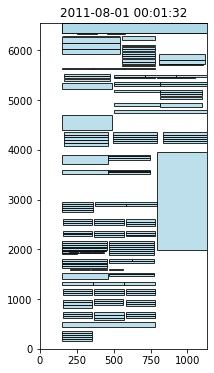

In [196]:
bb.plot_bounding_box_df(latimes_bounding_boxes[0], figsize=(3,6), clip_right=True)

# LATimes 2 years

In [722]:
reload(bb)

<module 'get_bounding_boxes_from_html' from '/Users/spangher/Projects/usc-research/newsworthiness/notebooks/../scripts-homepage-data/get_bounding_boxes_from_html.py'>

In [723]:
one_file = list(filter(lambda x: '20110801000132' in x, two_years_latimes_files))[0]

In [724]:
one_bb_df = await bb.get_bounding_box_one_file(
    file='file://' + os.getcwd() + '/' + one_file, filter_to_articles=False
)

/Users/spangher/Projects/usc-research/newsworthiness/notebooks/../scripts-homepage-data/get_bounding_boxes_from_html.py:480: RuntimeWarning: coroutine 'Browser.new_context' was never awaited
  browser.new_context(screen={


(1133.0, 6815.0, 1133.0, 6815.0)

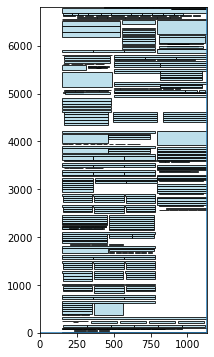

In [745]:
bb.plot_bounding_box_df(
    pd.DataFrame(one_bb_df['bounding_boxes']), 
    clip_right=True,
    figsize=(3, 6)   
)

In [746]:
wayback_scrape_dir = '../data/latimes-two-years/web.archive.org'
two_years_latimes_files = glob.glob(
    wayback_scrape_dir + '/web/*[!_]/latimes.com/*'
)

two_years_latimes_files = sorted(two_years_latimes_files, key=lambda x: x.split('/')[-3])

from more_itertools import unique_everseen
nested_files = glob.glob(
    wayback_scrape_dir + '/web/*[!_]/*/latimes.com/*'
)
for embedded_file in nested_files:
    unembedded_file = list(unique_everseen(embedded_file.split('/')))
    unembedded_file = '/'.join(unembedded_file)
    shutil.move(embedded_file, unembedded_file)

In [747]:
from datetime import datetime
date_strs = list(map(lambda x: x.split('/')[-3], two_years_latimes_files))
date_strs = list(map(lambda x: datetime.strptime(x, '%Y%m%d%H%M%S'), date_strs))

In [ ]:
latimes_bounding_boxes, _ = await bb.get_bounding_boxes_for_files(
    two_years_latimes_files, filter_to_articles=False
)

In [751]:
for bb_df in latimes_bounding_boxes:
    if bb_df is not None and len(bb_df) > 0:
        homepage_key = bb_df.iloc[0]['key']
        bb_df.to_csv(f'../data/8-years-latimes-homepage-no-article-filtering/homepage-{homepage_key}.csv')

In [ ]:
page, browser, playwright = await bb.instantiate_new_page_object(headless=False, block_external_files=False)

In [ ]:
# check to see if missing-CSS file is due to the single-file process or something else
await page.goto('file://' + os.getcwd() + '/' + two_years_latimes_files[21])
await page.goto('https://web.archive.org/web/20111020135716/latimes.com')
# conclusion: it's due to something else

# Label Documents to identify poorly-formatted ones

In [ ]:
labels = []
idx = len(labels)
for f, lat_bb in zip(two_years_latimes_files[idx:], latimes_bounding_boxes[idx:]):
    if len(lat_bb) < 2:
        labels.append(0)
        continue
        
    print(f)
    bb.plot_bounding_box_df(lat_bb, clip_right=False, figsize=(3,6))
    plt.show()
    label = input()
    labels.append(label)
    clear_output()

In [ ]:
await bb.draw_visual_bounding_boxes_on_page(file=f)

In [ ]:
X = latimes_bounding_boxes[:len(labels)]
y = labels

In [ ]:
data = {'X': X, 'y': y}
with open('cache/latimes-two-years-reject-training-data.pkl', 'wb') as f:
    pickle.dump(data, f)

In [9]:
with open('cache/latimes-two-years-reject-training-data.pkl', 'rb') as f:
    data = pickle.load(f)

In [10]:
X = data['X']
y = data['y']

In [ ]:
X_transformed = []

x_t = bb.transform_input_for_clustering(X[0])
default_row = pd.Series(0, index=x_t.index)

for x in tqdm(X):
    if len(x) == 0:
        X_transformed.append(default_row.copy())
    else:
        x_t = bb.transform_input_for_clustering(x, )
        X_transformed.append(x_t)
        
X_transformed = pd.concat(X_transformed, axis=1).T

In [ ]:
lr = LogisticRegressionCV()
X_train, X_test, y_train, y_test = train_test_split(X_transformed, y, test_size=.1)
lr.fit(X_train, y_train)

In [ ]:
## error rate: 1/10
lr.predict(X_test)

In [ ]:
with open('cache/2023-03-01__trained-latimes-lr-model.pkl', 'wb') as f:
    pickle.dump(lr, f)

In [11]:
with open('cache/2023-03-01__trained-latimes-lr-model.pkl', 'rb') as f:
    lr = pickle.load(f)

In [13]:
## how prevalent are these examples?
unlabeled_bbs = latimes_bounding_boxes[len(y):]

In [ ]:
x_t = bb.transform_input_for_clustering(X[0])
default_row = pd.Series(0, index=x_t.index)
unlabeled_transformed = []
for x in tqdm(unlabeled_bbs):
    if len(x) == 0:
        unlabeled_transformed.append(default_row.copy())
    else:
        x_t = bb.transform_input_for_clustering(x, )
        unlabeled_transformed.append(x_t)

unlabeled_transformed_df = pd.concat(unlabeled_transformed, axis=1).T
y_pred = lr.predict(unlabeled_transformed_df)

In [ ]:
t = list(itertools.compress(unlabeled_bbs, map(lambda x: x == "0", y_pred)))

# Article Files in LATimes

In [291]:
articles = (
    pd.concat(latimes_bounding_boxes)[['href', 'key']]
        .drop_duplicates()
        .loc[lambda df: df['href'].str.len() > 0]
        .reset_index(drop=True)
)

two_years_latimes_files_df = (
    pd.Series(two_years_latimes_files)
    .to_frame('files')
    .assign(size=lambda df: df['files'].apply(os.path.getsize))
    .reset_index(drop=True)
)

In [293]:
articles.to_csv('../data/latimes-article-urls-to-fetch.csv')

In [403]:
auth = open('../scripts/scrape_articles_gcf/gcf_auth.txt').read().strip()

In [406]:
url = 'https://wayback-scrape-v2-3-ukvxfz3sya-uw.a.run.app'
data = {
    'article_url': 'http://latimesblogs.latimes.com/lanow/2011/07/man-shot-and-killed-in-norwalk-sunday.html', 
    'homepage_key': '20110801000132'
}

# Create basic training data

In [1]:
import sys
sys.path.insert(0, '../scripts-homepage-data/')
import get_bounding_boxes_from_html as bb
from tqdm.auto import tqdm
import glob
import pandas as pd 
import jsonlines
from tqdm.auto import tqdm
from urllib.parse import urlencode, urlparse, urlunparse, parse_qs, urljoin
import spacy
from unidecode import unidecode
import re


def clean_url(url):
    if isinstance(url, float):
        return 
    return urljoin(url, urlparse(url).path)

spacy_model = spacy.load('en_core_web_lg')
spacy_model.add_pipe('sentencizer')

regex_replacers = [
    (r'"\s*([^"]*?)\s*"', r' "\1" '),
    ('\s+', ' '),
    #
    ('\.""', '." "'),
    ('\?""', '?" "'),
    ('\!""', '!" "'),
    # 
    ('\."(?=[\w])', '." '),
    ('\?"(?=[\w])', '?" '),
    ('\!"(?=[\w])', '!" '),
    #
    ('\.(?=[\w])', '. '),
    ('\?(?=[\w])', '? '),
    ('\!(?=[\w])', '! '),
    ('\:(?=[\w])', ': '),    
]

def process_text(text):
    text = unidecode(text)
    for p, r in regex_replacers:
        text = re.sub(p, r, text)
    return text.strip()

In [644]:
latimes_bounding_boxes = []
for csv_fn in tqdm(glob.glob('../data/8-years-latimes-homepage-csvs/*')):
    one_df = pd.read_csv(csv_fn)
    latimes_bounding_boxes.append(one_df)

In [752]:
fetched_file = [
    '../data/latimes-8-years.jsonl',
    '../data/latimes-output-round-2.jsonl'
]
article_data = []
for f in fetched_file:
    article_data += list(jsonlines.open(f) )
article_data_df = pd.DataFrame(article_data)

In [863]:
t = list(map(lambda x: x['page_width'].iloc[0], list(filter(lambda x: len(x) > 2, latimes_bounding_boxes))))

In [793]:
clipped_latimes_bounding_boxes = []
for bb_df in tqdm(latimes_bounding_boxes):
    if bb_df is not None and len(bb_df) > 0:
#         bb_df['page_width'] = bb.get_clipped_height_or_width(bb_df)
        bb_df['page_height'] = bb_df.pipe(lambda df: df['y'] + df['height']).max()
        clipped_latimes_bounding_boxes.append(bb_df)

clipped_latimes_bounding_boxes = {df.iloc[0]['key']: df for df in clipped_latimes_bounding_boxes}

  0%|          | 0/3255 [00:00<?, ?it/s]

In [794]:
all_bb_dfs = pd.concat(list(clipped_latimes_bounding_boxes.values()))
all_bb_dfs['key'] = all_bb_dfs['key'].astype(int)

all_bb_dfs['clean_href'] = all_bb_dfs['href'].apply(clean_url)
article_data_df['clean_article_url'] = article_data_df['article_url'].apply(clean_url)

In [796]:
article_data_df_w_hp_info = (article_data_df
 .merge(all_bb_dfs, left_on=['homepage_key', 'clean_article_url'], right_on=['key', 'clean_href'])
 .drop_duplicates(['article_url', 'homepage_key'])
 .assign(perc_height=lambda df: df['y'] / df['page_height'])
 .assign(perc_width=lambda df: (df['x'] / df['page_width']).apply(lambda x: min(x, 1)))
)

In [872]:
all_bb_dfs['clean_href'].isin(article_data_df['clean_article_url']).value_counts()

False    511230
True     393199
Name: clean_href, dtype: int64

In [798]:
unfound_urls_w_bbs = (
    all_bb_dfs
     .loc[lambda df: ~df['href'].isin(article_data_df['article_url'])]
)

unfound_urls = unfound_urls_w_bbs['href'].str.split('#').str.get(0)

In [806]:
unfound_urls.value_counts().loc[lambda s: s == 5]

http://www.latimes.com/food/dailydish/la-dd-vending-machines-westfield-century-city-20151209-story.html                                 5
http://www.latimes.com/politics/la-na-pol-essential-washington-updates-texas-republican-resigns-in-wake-of-1523050114-htmlstory.html    5
http://www.latimes.com/business/la-fi-nafta-react-20181001-story.html                                                                   5
http://www.latimes.com/nation/nationnow/la-na-texas-redistricting-20170311-story.html                                                   5
http://www.latimes.com/business/la-fi-redfin-ipo-20170727-story.html                                                                    5
                                                                                                                                       ..
http://www.latimes.com/food/dailydish/la-dd-gold-live-chat-20170517-htmlstory.html                                                      5
http://www.latimes.com/travel/la-t

In [14]:
# make training data

(3000.0, 16532.5234375, 1280.0, 16637.5234375)

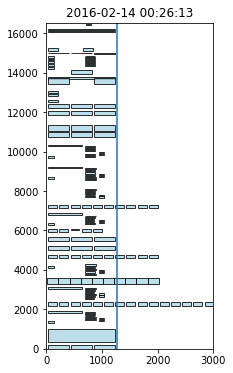

In [907]:
bb.plot_bounding_box_df(
    article_data_df_w_hp_info
     .loc[lambda df: df['homepage_key'] == 20160214002613],
    figsize=(3, 6)
)

In [910]:
training_data = (article_data_df_w_hp_info
 .assign(label=lambda df: df['perc_height'] < .5)
 .assign(area=lambda df: df['width'] * df['height'])
 [['article_url', 'homepage_key', 'article_text', 'perc_height', 
   'perc_width', 'label', 'area', 'width', 'height', 'x', 'y']]
)

In [897]:
training_data = (training_data
 .pipe(lambda df: 
      pd.concat([
          df.groupby('article_url')['homepage_key'].aggregate(list).to_frame('homepage_keys'),
          df.groupby('article_url')['article_text'].aggregate(list).str.get(0).to_frame('article_text'),
          df.groupby('article_url')[['perc_height', 'perc_width', 'area', 'width', 'height', 'x', 'y']].mean()          
      ], axis=1)
  )
)

In [912]:
tqdm.pandas()

t = training_data['article_text'].drop_duplicates().progress_apply(process_text)
all_sentences = []
for doc in tqdm(spacy_model.pipe(
    t.tolist(), 
    disable=["ner", "tok2vec", "tagger", "parser", "attribute_ruler", "lemmatizer"]
), total=len(t)):
    sents = list(doc.sents)
    sents = list(map(str, sents))
    all_sentences.append(sents)

  0%|          | 0/173561 [00:00<?, ?it/s]

  0%|          | 0/173561 [00:00<?, ?it/s]

In [918]:
text_to_sents = training_data['article_text'].drop_duplicates().to_frame().assign(sentences=all_sentences)

In [919]:
text_to_sents

,article_text,sentences
0,Dental Health\n\nBraces aren't just for kids a...,[Dental Health Braces aren't just for kids any...
1,"Braylon Edwards, a free-agent receiver who wan...","[Braylon Edwards, a free-agent receiver who wa..."
2,Fans filing into Comerica Park on Sunday were ...,[Fans filing into Comerica Park on Sunday were...
3,"In America's movie theaters, this has been the...","[In America's movie theaters, this has been th..."
6,It's the first rule of thumb for any aspiring ...,[It's the first rule of thumb for any aspiring...
...,...,...
426818,Get AccuWeather alerts as they happen with our...,[Get AccuWeather alerts as they happen with ou...
426819,LeBron James will miss another game because of...,[LeBron James will miss another game because o...
426854,"Late Tuesday night, William Gude took to his T...","[Late Tuesday night, William Gude took to his ..."
426855,The House on Wednesday passed legislation desi...,[The House on Wednesday passed legislation des...


In [921]:
training_data = (training_data
 .merge(text_to_sents, left_on='article_text', right_on='article_text', how='left')
)

In [899]:
# training_data['sentences'] = all_sentences

In [922]:
training_data.to_json('../modeling/data/latimes-homepage-placement-labeling-no-article-filter.jsonl', orient='records', lines=True)

In [692]:
one_bb_df = (
    article_data_df_w_hp_info
     .loc[lambda df: df['homepage_key'] == 20110801000132]
)

In [698]:
one_bb_df.iloc[0]

article_url                       http://www.latimes.com/health/dentalhealth/hk-...
homepage_key                                                         20110801000132
article_text                      Dental Health\n\nBraces aren't just for kids a...
article_publish_date                                                           None
article_authors                                                                  []
article_top_image                 https://web.archive.org/web/20110801025600im_/...
article_video                                                                    []
article_wayback_timestamp                                            20110801025600
all_article_wayback_timestamps    [20110801025600, 20110802095708, 2011080509590...
clean_article_url                 http://www.latimes.com/health/dentalhealth/hk-...
Unnamed: 0                                                                        0
href                              http://www.latimes.com/health/dentalhealth

(1133.0, 6558.0, 1133.0, 6598.0)

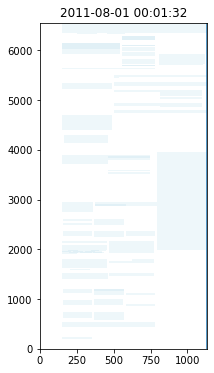

In [696]:
bb.plot_bounding_box_df(
    bb_df=one_bb_df, 
    figsize=(3, 6),
    clip_right=True, 
    url_to_filter='http://www.latimes.com/health/dentalhealth/hk-dental-health-gallery,0,1236531.storygallery'
)

# Find articles in the common crawl

In [16]:
import urllib
import gzip
import json
import requests
import pandas as pd 
from bs4 import BeautifulSoup
import urllib

# Let's fetch the Common Crawl FAQ using the CC index
esc_url = urllib.parse.quote_plus(unfound_urls.value_counts().index[4])
common_crawl_indices_page = requests.get('https://index.commoncrawl.org/').text
soup = BeautifulSoup(common_crawl_indices_page)
table = soup.find('table')

all_rows = []
header = list(map(lambda x: x.get_text(), table.find_all('th')))
rows = table.find_all('tr')[1:]

for tr in rows:
    td = tr.find_all('td')
    to_append = {k:d for k,d in zip(header, td)}
    to_append_with_links = {}
    for c_head, c in to_append.items():
        if c.find('a'):
            to_append_with_links[f'{c_head} Link'] = c.find('a').attrs.get('href')
        to_append_with_links[c_head] = c.get_text()

    all_rows.append(to_append_with_links)

common_crawl_table = pd.DataFrame(all_rows)

In [17]:
unfound_urls_w_keys = unfound_urls_w_bbs.groupby('href')['key'].aggregate(list)

In [18]:
url = unfound_urls_w_keys.index[0]
hp_key = unfound_urls_w_keys[url][0]

In [19]:
from datetime import datetime

In [20]:
import re 
def get_month_from_name(month_name):
    return datetime.strptime(month_name, '%B').month

def parse_cc_crawl_date(name):
    year = re.search('\d{4}', name)[0]
    months = name.split(' ')[0]
    output_dates = []
    for m in months.split('/'):
        output_dates.append(( get_month_from_name(m), year))
    return output_dates

In [ ]:
(common_crawl_table['Crawl']
 .loc[lambda s: ~s.str.contains('ARC')]
 .str.replace('Winter', 'January/February')
 .str.replace('Summer', 'June/July/August')
 .apply(parse_cc_crawl_date)
)

In [22]:
dt = datetime.strptime(str(hp_key), '%Y%m%d%H%M%S')

In [24]:
common_crawl_table['API endpoint']

0       /CC-MAIN-2023-06-index
1       /CC-MAIN-2022-49-index
2       /CC-MAIN-2022-40-index
3       /CC-MAIN-2022-33-index
4       /CC-MAIN-2022-27-index
                ...           
88      /CC-MAIN-2013-48-index
89      /CC-MAIN-2013-20-index
90         /CC-MAIN-2012-index
91    /CC-MAIN-2009-2010-index
92    /CC-MAIN-2008-2009-index
Name: API endpoint, Length: 93, dtype: object

In [419]:
from IPython.display import HTML, display
import re
from io import StringIO , BytesIO
from datetime import datetime
import tldextract
from urllib.parse import urlparse

In [305]:
domain = "sfchronicle.com"

In [ ]:
url_base = 'http://localhost:8080'
all_keys= []
all_lines = []

for index in tqdm(common_crawl_table['API endpoint']):
    i = 0
    index = index.replace('/', '')
    while True:
        resp = requests.get(f'{url_base}/{index}?url={domain}/*&page={i}')
        # 
        if resp.status_code == 200:
            lines = resp.text.split('\n')
            keys = list(map(get_key, lines))
            all_keys += keys
            all_lines += lines
            i += 1
        else:
            break

In [570]:
import gzip
with gzip.open('../data/sfchron-cc-to-fetch.txt.gz', 'wb') as f:
    for line in all_lines:
        f.write(line.encode())
        f.write(b'\n')

In [ ]:
count = 0
with gzip.open('../data/sfchron-cc-to-fetch.txt.gz', 'rb') as f:
    for line in f:
        print(line)
        count += 1
        if count == 5:
            break

In [471]:
all_keys = list(filter(lambda x: len(x) > 2, all_keys))
all_keys = (
    pd.Series(list(map(lambda x: x.split()[0], all_keys)))
    .str.split('?')
    .str.get(0)
)
article_counts = all_keys.value_counts()
unique_articles = article_counts.index.tolist()

In [477]:
# check overlap
sfchron_articles_to_fetch_from_homepage = pd.read_csv('../data/sfchron-article-urls-to-fetch.csv.gzip', compression='gzip')

sfchron_articles_to_fetch_from_homepage['href'] = (
    sfchron_articles_to_fetch_from_homepage['href']
     .apply(lambda x: urlparse(x).path)
     .str.strip().str.lower()
)

unique_articles = pd.Series(unique_articles).str.replace('com,sfchronicle\)', '', regex=True).str.strip()

In [478]:
sfchron_articles_to_fetch_from_homepage['href'].drop_duplicates().isin(unique_articles).value_counts()

True     46403
False    36860
Name: href, dtype: int64

# Get articles from index information

In [635]:
def make_output_data(row):
    output_packet = json.loads(row['json_str'])
    output_packet['article_url'] = row['url']
    output_packet['scrape_timestamp'] = row['timestamp']
    return output_packet

In [494]:
from more_itertools import unique_everseen
get_key = lambda x: re.sub('\{.*\}', '', x).strip()
get_json_body = lambda x: re.search('\{.*\}', x)[0]

unique_article_lines = list(filter(lambda x: len(x) > 2, all_lines))
unique_article_lines = list(unique_everseen(unique_article_lines, key=lambda x: x.split()[0].split('?')[0]))

In [638]:
t = (pd.Series(unique_article_lines)
 .to_frame('data')
 .assign(json_str=lambda df: df['data'].apply(get_json_body))
 .assign(key=lambda df: df['data'].apply(get_key).str.split())
 .loc[lambda df: df['key'].str.len() == 2]
 .assign(url=lambda df: df['key'].str.get(0))
 .assign(timestamp=lambda df: df['key'].str.get(1))
#  .apply(make_output_data, axis=1)
)

In [506]:
prefix = 'https://data.commoncrawl.org/'

# get page data
for line in tqdm(unique_article_lines):
    try:
        json_str = get_json_body(line)
        page = json.loads(json_str)
    except:
        print(line)
        continue

    offset, length = int(page['offset']), int(page['length'])
    offset_end = offset + length - 1
    # We can then use the Range header to ask for just this set of bytes
    resp = requests.get(prefix + page['filename'], headers={'Range': 'bytes={}-{}'.format(offset, offset_end)})
    if resp.status_code == 503:
        print('503...')
        break
    raw_data = BytesIO(resp.content)
    f = gzip.GzipFile(fileobj=raw_data)

    # What we have now is just the WARC response, formatted:
    data = f.read()
    warc, header, response = data.decode().strip().split('\r\n\r\n', 2)

  0%|          | 0/242525 [00:00<?, ?it/s]

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): data.commoncrawl.org:443
DEBUG:urllib3.connectionpool:https://data.commoncrawl.org:443 "GET /crawl-data/CC-MAIN-2023-06/segments/1674764494974.98/warc/CC-MAIN-20230127065356-20230127095356-00360.warc.gz HTTP/1.1" 206 60315
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): data.commoncrawl.org:443
DEBUG:urllib3.connectionpool:https://data.commoncrawl.org:443 "GET /crawl-data/CC-MAIN-2023-06/segments/1674764500837.65/warc/CC-MAIN-20230208155417-20230208185417-00540.warc.gz HTTP/1.1" 206 29077
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): data.commoncrawl.org:443
DEBUG:urllib3.connectionpool:https://data.commoncrawl.org:443 "GET /crawl-data/CC-MAIN-2023-06/segments/1674764500041.2/crawldiagnostics/CC-MAIN-20230202232251-20230203022251-00654.warc.gz HTTP/1.1" 206 13342
DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): data.commoncrawl.org:443
DEBUG:urllib3.connectionpool:https://da

503...


In [525]:
import copy
page_data = copy.copy(page)

In [529]:
key = get_key(line)

In [532]:
url, timestamp = key.split()

In [533]:
page_data['article_url'] = url
page_data['scrape_timestamp'] = timestamp

In [543]:
url = 'http://localhost:8080'
url = "https://common-crawl-scrape-v1-ukvxfz3sya-uw.a.run.app"

In [549]:
t = requests.post(
    url,
    headers={
        'Content-Type': 'application/json'
    },
    data=json.dumps(page_data)    
)

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): common-crawl-scrape-v1-ukvxfz3sya-uw.a.run.app:443
DEBUG:urllib3.connectionpool:https://common-crawl-scrape-v1-ukvxfz3sya-uw.a.run.app:443 "POST / HTTP/1.1" 200 164382


# Process LATimes articles to fetch from Common Crawl

In [813]:
import storysniffer

In [815]:
sniffer = StorySniffer()

In [838]:
seen = set()
total_lines = 0
output_lines = []
with gzip.open('../data/latimes-cc-articles-to-fetch.jsonl.gz', 'rb') as f:
    for line in tqdm(f):
        total_lines += 1
        line = line.decode()
        key = get_key(line)
        url = key.split(' ')[0]
        url = url.replace('com,latimes)', '').split('?')[0]
        if url in seen:
            continue
        seen.add(url)
        if sniffer.guess(url) == False:
            continue
        output_lines.append(line)

0it [00:00, ?it/s]

In [839]:
len(output_lines)

2849860

In [840]:
with gzip.open('../data/latimes-cc-articles-to-fetch-unique.jsonl.gz', 'wb') as f:
    for line in output_lines:
        f.write(line.encode())
        f.write(b'\n')

In [861]:
all_urls = list(map(lambda x: get_key(x).split()[0], output_lines))

# Testing ground for some light cleanup

In [607]:
i = 'Hello!""There'
c = i
for p, r in eos_punctuation:
    o = re.sub(p, r, i)
    c = re.sub(p, r, c)
    print(o)
    print(c)
    print()

Hello!""There
Hello!""There

Hello!""There
Hello!""There

Hello!" "There
Hello!" "There

Hello!""There
Hello!" "There

Hello!""There
Hello!" "There

Hello!""There
Hello!" "There

Hello!""There
Hello!" "There

Hello!""There
Hello!" "There

Hello!""There
Hello!" "There



In [ ]:
from subprocess import Popen, PIPE, run, check_call

output, err = Popen([
    "waybackpack",
    'latimes.com',
    "--from-date",
    "20180101",
    "--to-date",
    "20221201",
    "--list",
    '--user-agent',
    'waybackpack-spangher@usc.edu'
], stdin=PIPE, stdout=PIPE, stderr=PIPE).communicate()

urls = output.decode().strip().split('\n')

epoch_time = datetime(1970, 1, 1)

def get_time_from_waybackpack_url(url_str: str):
    """
    Extracts the date string from a waybackurl and converts it to total_seconds from 1970/1/1
        :type url_str: str
    """
    date_str = url_str.split('/')[4]
    dt = datetime.strptime(date_str, '%Y%m%d%H%M%S')
    return int((dt - epoch_time).total_seconds())

url_s = list(map(get_time_from_waybackpack_url, urls))

buckets = list(range(url_s[0], url_s[-1], timeparse('1d')))
time_bins = list(map(lambda x: np.digitize(x, buckets, right=True), url_s))

collapsed_groups = []
for g, g_iter in groupby(zip(time_bins, url_s), key=lambda x: x[0]):
    t = list(map(lambda x: x[1], g_iter))
    collapsed_groups.append(t)

collapsed_groups[0]

In [ ]:
cc_aws_directories = ! aws s3 ls --recursive s3://commoncrawl/cc-index/collections/

cc_aws_directories = list(map(lambda x: x.split()[-1], cc_aws_directories))

cc_aws_dirs_to_copy = list(filter(lambda x: ("cluster.idx" in x) or ("metadata.yaml" in x), cc_aws_directories))

src = 's3://commoncrawl/'
dest = '../scripts-article-data/scrape_articles_cc/cc-index-server/collections/'
path_to_remove = 'cc-index/collections/'

for file in tqdm(cc_aws_dirs_to_copy):
    dest_fp = dest + file.replace(path_to_remove, '')
    dest_dir = os.path.dirname(dest_fp)
    os.makedirs(dest_dir, exist_ok=True)
    src_fp = src + file
    ! aws s3 cp $src_fp $dest_dir